# Academic CCG Metrics

Metrics commonly used in CCG analysis that are supported by the current training logs.

The academic literature around CCGs commonly analyzes diversity, meta share, weighted performance against the current meta, matchup balance, viable archetype count, and card-level contribution. This notebook adapts the metrics that are valid for the data currently logged by this project.

Important distinction:

- Deck-level and composition-level metrics are supported because `train.db` stores generated decks, deck-builder fitness, deck-vs-deck matches, and player-controller match samples.
- True drawn-card, played-card, position, ability-use, mana, round, and dragon-event metrics are not yet supported because `game_loop.py` does not persist those events.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
while project_root.name != "Draci_zvesti_merged" and project_root.parent != project_root:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from neat_ai.analysis.academic_metrics import get_supported_academic_metrics
from neat_ai.analysis.insight_charts import (
    plot_meta_entropy_timeline,
    plot_weighted_meta_performance,
    plot_matchup_balance_timeline,
    plot_viable_archetypes_timeline,
    plot_card_presence_lift_timeline,
)

project_root

PosixPath('/home/electro/Personal/UPOL/Draci_zvesti_merged')

## Supported Metrics

This table documents which common academic CCG metrics are available from the current logs.

How to read it:

- `supported = True` means the metric can be computed from existing SQLite data.
- `supported = False` means the game already performs that action at runtime, but the event is not written to the database.
- This matters for academic reporting: card presence lift is a valid deck-composition proxy, but it should not be described as drawn-card or played-card win rate.

In [2]:
get_supported_academic_metrics()

,metric,supported,reason
0,Meta diversity / Shannon entropy,True,Deck signatures and outer generations are logged.
1,Weighted performance versus meta,True,Deck matchups and generation-local deck preval...
2,Matchup balance / polarization,True,Deck-vs-deck controller scores are logged in p...
3,Viable archetype count,True,Can derive from weighted meta score by generat...
4,Card presence lift,True,Deck composition and genome fitness are logged.
5,Card drawn/played win rate,False,game_loop.py draws and places cards but does n...
6,Ability-use or position statistics,False,Choice position/use_ability values are not wri...
7,Round/mana/dragon event statistics,False,"Rounds, mana state, and dragon battles are run..."


## Meta Diversity

This graph answers: is training converging to a narrow meta or maintaining many distinct archetypes?

The chart shows normalized Shannon entropy and top-archetype share. Entropy measures how evenly deck signatures are distributed. Top-archetype share measures how much of the population is occupied by the most common archetype.

How to read it:

- High normalized entropy means the population is diverse.
- Low normalized entropy means the population is concentrating around fewer archetypes.
- Rising top-archetype share means one archetype is starting to dominate.
- `effective_archetypes = 2 ** entropy` is a readable estimate of how many equally common archetypes the diversity resembles.

Current caveat: many generated decks currently have unique signatures, so entropy may look high until signatures are clustered into broader archetype families.

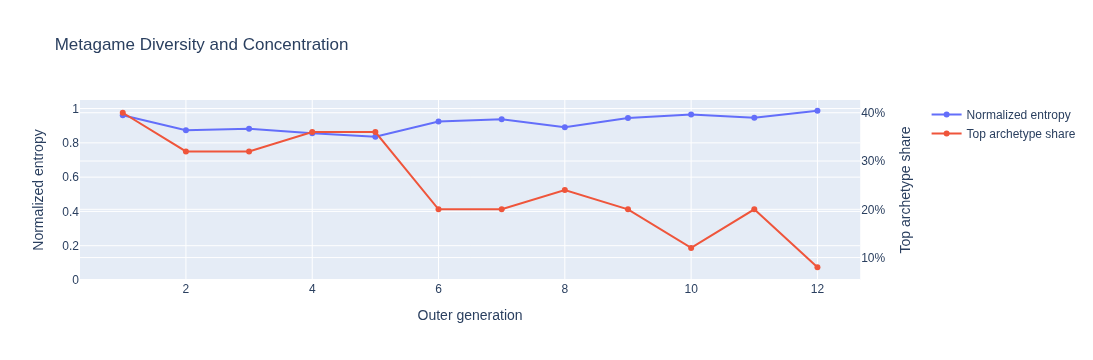

In [3]:
plot_meta_entropy_timeline(group_count=None).show()

## Weighted Performance Versus Meta

This graph answers: which archetypes perform best against the opponents that actually exist in the same generation group?

The metric weights each deck's matchup score by opponent prevalence in the same generation. That is closer to academic "performance versus the meta" than a raw average over every opponent.

How to read it:

- High weighted meta score means the deck performs well into common local opponents.
- High raw average but lower weighted score means the deck beats rare opponents more than common ones.
- Strong late-generation decks are more relevant to the final trained meta than decks that dominated only early weaker opponents.
- Generation 1 is excluded where local genome prevalence cannot be joined reliably.

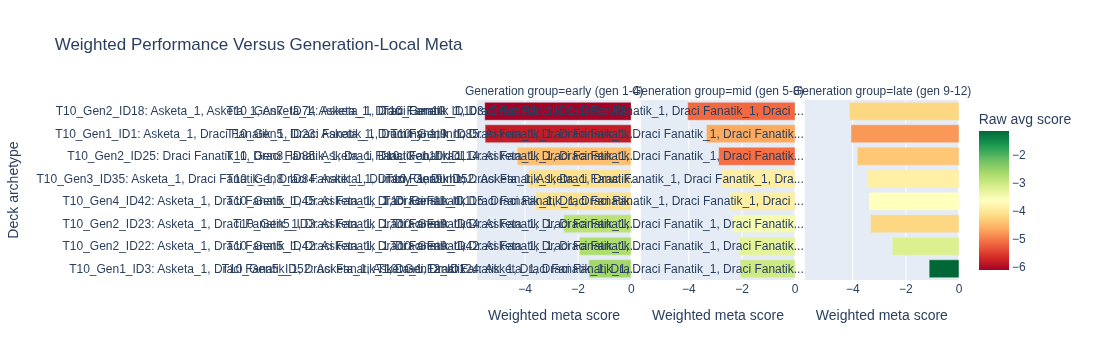

In [4]:
plot_weighted_meta_performance(group_count=3, top_n_per_group=8).show()

## Matchup Balance

This graph answers: are matchups becoming closer to balanced, or more polarized?

The main line is mean absolute deck score. Lower values are closer to neutral matchups. The secondary line is close-matchup rate, the share of samples near even.

How to read it:

- Falling mean absolute score means matchups are becoming less one-sided.
- Rising close-matchup rate means more deck pairs are near even.
- High maximum absolute score means at least one very polarized matchup remains.
- Some polarization is normal in CCGs, but too much can imply hard counters and a fragile meta.

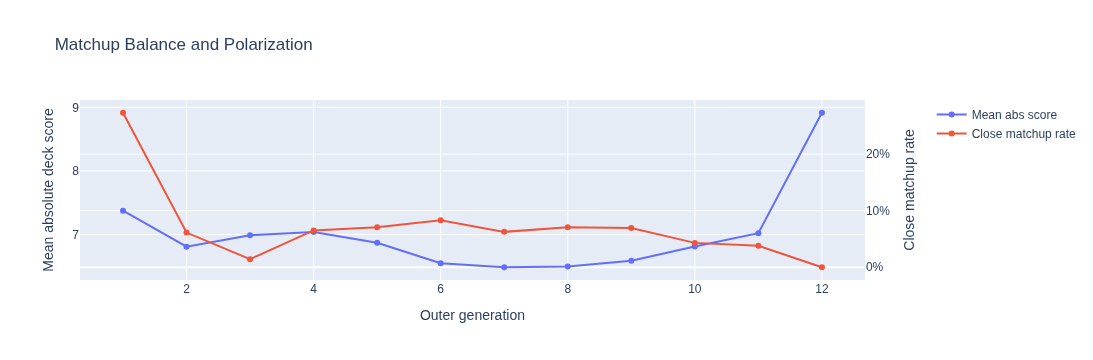

In [5]:
plot_matchup_balance_timeline(group_count=None).show()

## Viable Archetypes

This graph answers: how many archetypes are at least competitive against their generation-local meta?

By default, an archetype is counted as viable when its weighted meta score is at least `0.0`. This means it is not losing on average against local opponents after opponent prevalence is considered.

How to read it:

- High viable share means many decks can compete.
- Low viable share means the meta is narrow.
- A high best score combined with low viable share suggests one or a few decks dominate.
- Raising `viability_threshold` makes the definition stricter.

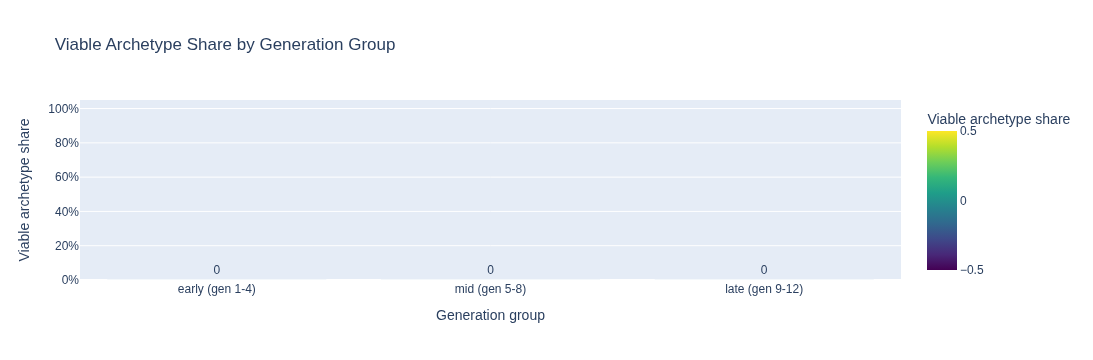

In [6]:
plot_viable_archetypes_timeline(group_count=3, viability_threshold=0.0).show()

## Card Presence Lift

This graph answers: which cards are associated with better decks within each generation group?

Presence lift is average fitness of decks containing the card minus baseline average fitness for the same generation group. This keeps early weak decks and late stronger decks separated.

How to read it:

- Positive lift means the card appears in better-than-average decks for that group.
- A card with high lift and high pick rate is a strong balance candidate.
- A card with high lift but low pick rate is a possible underexplored card.
- A card with high pick rate but negative lift may be over-selected by the deck builder.

Important limitation: this is a deck-composition statistic, not drawn win rate or played win rate.

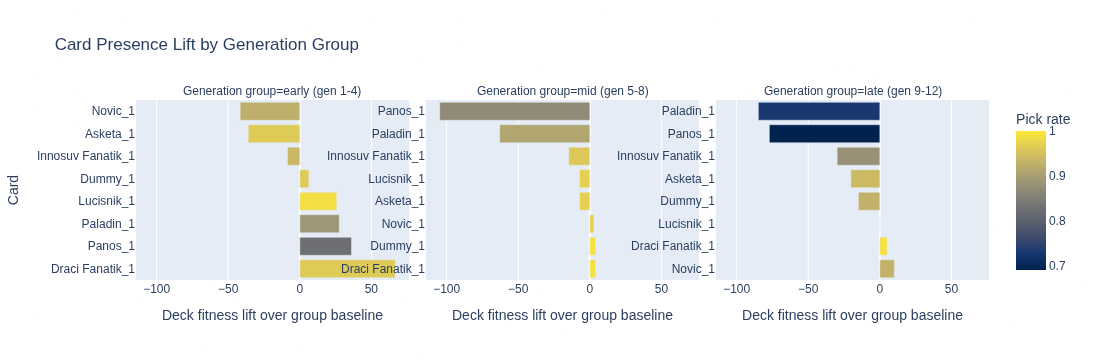

In [7]:
plot_card_presence_lift_timeline(group_count=3, top_n_per_group=8, min_times_played=2).show()